# Notebook de Tests basiques 

In [1]:
import torch
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(project_root)

import sys
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
from src.envs.env_toy_mm import MMSimulator
from src.ppo.networks import ActorNet, CriticNet
from src.utils.device import get_device
from scripts.train_loop import collect_trajectory

# Device
device = get_device()

# Instanciation
env = MMSimulator(csv_path="data/raw/toy_lob.csv", seed=42)


[Device] Using mps
[Device] Using mps


In [3]:

actor = ActorNet(
    state_dim=4,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

# Test collecte
trajectory = collect_trajectory(env, actor, device)

# Récupération
states = trajectory["states"]
actions = trajectory["actions"]
rewards = trajectory["rewards"]
old_log_probs = trajectory["old_log_probs"]

# Vérifications
print("Shapes :")
print("states       :", states.shape)
print("actions      :", actions.shape)
print("rewards      :", rewards.shape)
print("log_probs    :", old_log_probs.shape)

print("\nTypes :")
print("states       :", states.dtype, states.device)
print("actions      :", actions.dtype, actions.device)
print("rewards      :", rewards.dtype, rewards.device)
print("log_probs    :", old_log_probs.dtype, old_log_probs.device)

print("\nSanity checks :")
print("nb steps     :", len(rewards))
print("reward mean  :", rewards.mean().item())
print("reward std   :", rewards.std().item())
print("action range :", actions.min().item()," ,", actions.max().item())

Shapes :
states       : torch.Size([200, 4])
actions      : torch.Size([200, 1])
rewards      : torch.Size([200])
log_probs    : torch.Size([200, 1])

Types :
states       : torch.float32 mps:0
actions      : torch.float32 mps:0
rewards      : torch.float32 mps:0
log_probs    : torch.float32 mps:0

Sanity checks :
nb steps     : 200
reward mean  : -0.008881296962499619
reward std   : 0.11733610183000565
action range : 0.00022124499082565308  , 0.04970378428697586


In [4]:
actor = ActorNet(
    state_dim=4,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)
state = env.reset_random(max_steps=200)
trajectory = collect_trajectory(env, actor, device)

# Récupération
states = trajectory["states"]
actions = trajectory["actions"]
rewards = trajectory["rewards"]
old_log_probs = trajectory["old_log_probs"]

# Vérifications
print("Shapes :")
print("states       :", states.shape)
print("actions      :", actions.shape)
print("rewards      :", rewards.shape)
print("log_probs    :", old_log_probs.shape)

print("\nTypes :")
print("states       :", states.dtype, states.device)
print("actions      :", actions.dtype, actions.device)
print("rewards      :", rewards.dtype, rewards.device)
print("log_probs    :", old_log_probs.dtype, old_log_probs.device)

print("\nSanity checks :")
print("nb steps     :", len(rewards))
print("reward mean  :", rewards.mean().item())
print("reward std   :", rewards.std().item())
print("action range :", actions.min().item()," ,", actions.max().item())

Shapes :
states       : torch.Size([200, 4])
actions      : torch.Size([200, 1])
rewards      : torch.Size([200])
log_probs    : torch.Size([200, 1])

Types :
states       : torch.float32 mps:0
actions      : torch.float32 mps:0
rewards      : torch.float32 mps:0
log_probs    : torch.float32 mps:0

Sanity checks :
nb steps     : 200
reward mean  : 0.014467835426330566
reward std   : 0.18358027935028076
action range : 3.221482256776653e-05  , 0.049899887293577194


In [5]:
actor = ActorNet(
    state_dim=4,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)
state = env.reset_random(max_steps=200)
trajectory = collect_trajectory(env, actor, device)

# Récupération
states = trajectory["states"]
actions = trajectory["actions"]
rewards = trajectory["rewards"]
old_log_probs = trajectory["old_log_probs"]

# Vérifications
print("Shapes :")
print("states       :", states.shape)
print("actions      :", actions.shape)
print("rewards      :", rewards.shape)
print("log_probs    :", old_log_probs.shape)

print("\nTypes :")
print("states       :", states.dtype, states.device)
print("actions      :", actions.dtype, actions.device)
print("rewards      :", rewards.dtype, rewards.device)
print("log_probs    :", old_log_probs.dtype, old_log_probs.device)

print("\nSanity checks :")
print("nb steps     :", len(rewards))
print("reward mean  :", rewards.mean().item())
print("reward std   :", rewards.std().item())
print("action range :", actions.min().item()," ,", actions.max().item())

Shapes :
states       : torch.Size([200, 4])
actions      : torch.Size([200, 1])
rewards      : torch.Size([200])
log_probs    : torch.Size([200, 1])

Types :
states       : torch.float32 mps:0
actions      : torch.float32 mps:0
rewards      : torch.float32 mps:0
log_probs    : torch.float32 mps:0

Sanity checks :
nb steps     : 200
reward mean  : 0.026897521689534187
reward std   : 0.6403399109840393
action range : 9.621828939998522e-05  , 0.04992956668138504


In [6]:
import torch
import time

import scripts.train_loop as tr_lp
# Device
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")

# Environnement
env = MMSimulator(csv_path="data/raw/toy_lob.csv", seed=42)

# Réseaux
actor = ActorNet(
    state_dim=4,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

critic = CriticNet(
    state_dim=4,
    hidden_size=64,
    n_layers=3
).to(device)

# Optimiseurs
actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

# Test d'un épisode
t0 = time.time()

l_history_critic, l_history_actor, episode_return = tr_lp.train_one_episode(
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_epochs_actor=5,
    n_epochs_critic=5,
    random_reset=True,
    max_steps=200,
    verbose=True,
)

elapsed = time.time() - t0

print("\n--- Résumé test train_one_episode ---")
print("critic history length :", len(l_history_critic))
print("actor history length  :", len(l_history_actor))
print("critic last loss      :", l_history_critic[-1])
print("actor last loss       :", l_history_actor[-1])
print("episode return        :", episode_return)
print("elapsed time          :", elapsed)

[train_critic]
[fit_critic] epoch=1/5 loss=6.0170e-01
[train_actor]
[fit_actor] epoch=1/5 loss=1.5856e-03

--- Résumé test train_one_episode ---
critic history length : 5
actor history length  : 5
critic last loss      : 0.4696647524833679
actor last loss       : -0.007520830724388361
episode return        : tensor(1.2465, device='mps:0')
elapsed time          : 0.47850894927978516


In [7]:
assert len(l_history_critic) == 5
assert len(l_history_actor) == 5
assert not torch.isnan(torch.tensor(l_history_critic)).any()
assert not torch.isnan(torch.tensor(l_history_actor)).any()
print("Tests simples passés.")

Tests simples passés.


In [17]:
import torch
import matplotlib.pyplot as plt
import time
import scripts.train_loop as tr_lp

# Device
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")

# Environnement
env = MMSimulator(csv_path="data/raw/toy_lob.csv", seed=42)

# Réseaux
actor = ActorNet(
    state_dim=4,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

critic = CriticNet(
    state_dim=4,
    hidden_size=64,
    n_layers=3
).to(device)

# Optimiseurs
actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

# Test boucle globale
t0 = time.time()

history = tr_lp.train_actor_critic(
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_episodes=200,          # volontairement petit
    n_epochs_actor=5,
    n_epochs_critic=5,
    random_reset=True,
    max_steps=200,
    verbose=False
)

elapsed = time.time() - t0

print("Temps total :", elapsed)

# Récupération
critic_loss = history["critic_loss"]
actor_loss = history["actor_loss"]
returns = history["episode_return"]

print("\n--- Sanity checks ---")
print("Nb épisodes :", len(returns))
print("Critic loss (last) :", critic_loss[-1])
print("Actor loss  (last) :", actor_loss[-1])
print("Return moyen :", sum(returns)/len(returns))
print("Return min / max :", min(returns), max(returns))

Temps total : 78.44849276542664

--- Sanity checks ---
Nb épisodes : 200
Critic loss (last) : 0.001138635678216815
Actor loss  (last) : 0.5
Return moyen : tensor(-0.3134)
Return min / max : tensor(-43.9026) tensor(8.3683)


In [9]:
assert len(critic_loss) == 20
assert len(actor_loss) == 20
assert len(returns) == 20

assert not any([torch.isnan(torch.tensor(x)) for x in critic_loss])
assert not any([torch.isnan(torch.tensor(x)) for x in actor_loss])
print("Tests simples passés.")

Tests simples passés.


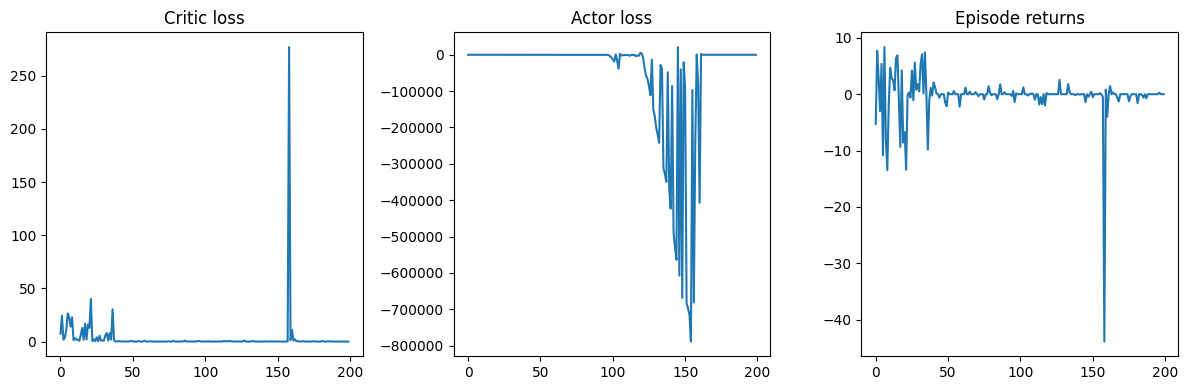

In [18]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(critic_loss)
plt.title("Critic loss")

plt.subplot(1,3,2)
plt.plot(actor_loss)
plt.title("Actor loss")

plt.subplot(1,3,3)
plt.plot(returns)
plt.title("Episode returns")

plt.tight_layout()
plt.show()

In [14]:
import torch
import matplotlib.pyplot as plt
import time
import scripts.train_loop as tr_lp

# Device
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")

# Environnement
env = MMSimulator(csv_path="data/raw/toy_lob.csv", seed=42)

# Réseaux
actor = ActorNet(
    state_dim=4,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

critic = CriticNet(
    state_dim=4,
    hidden_size=64,
    n_layers=3
).to(device)

# Optimiseurs
actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

# Test boucle globale
t0 = time.time()

history = tr_lp.train_ppo(
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_episodes=200,          # volontairement petit
    n_epochs_actor=5,
    n_epochs_critic=5,
    random_reset=True,
    max_steps=200,
    verbose=False
)

elapsed = time.time() - t0

print("Temps total :", elapsed)

# Récupération
critic_loss = history["critic_loss"]
actor_loss = history["actor_loss"]
returns = history["episode_return"]

print("\n--- Sanity checks ---")
print("Nb épisodes :", len(returns))
print("Critic loss (last) :", critic_loss[-1])
print("Actor loss  (last) :", actor_loss[-1])
print("Return moyen :", sum(returns)/len(returns))
print("Return min / max :", min(returns), max(returns))

Temps total : 80.17328310012817

--- Sanity checks ---
Nb épisodes : 200
Critic loss (last) : 2.559112787246704
Actor loss  (last) : 0.0004994433838874102
Return moyen : -0.5033886077255011
Return min / max : -22.445693969726562 15.009064674377441


In [12]:
assert len(critic_loss) == 20
assert len(actor_loss) == 20
assert len(returns) == 20

assert not any([torch.isnan(torch.tensor(x)) for x in critic_loss])
assert not any([torch.isnan(torch.tensor(x)) for x in actor_loss])
print("Tests simples passés.")

Tests simples passés.


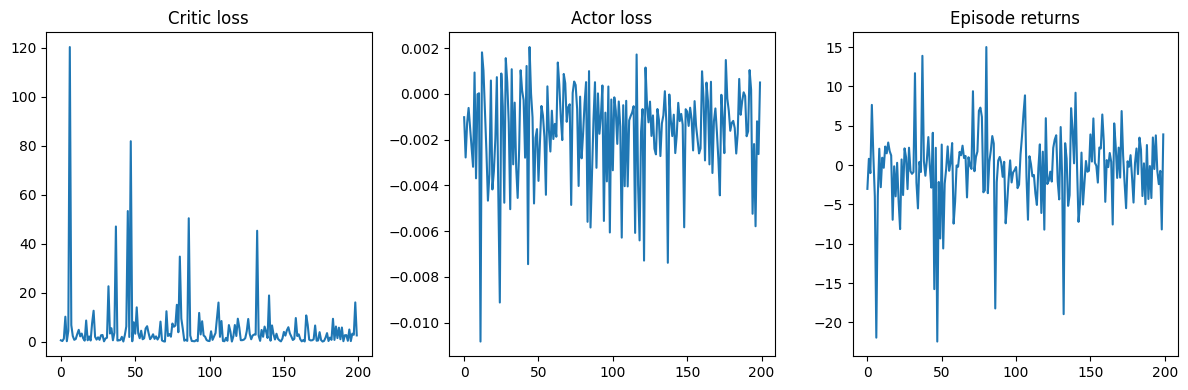

In [16]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(critic_loss)
plt.title("Critic loss")

plt.subplot(1,3,2)
plt.plot(actor_loss)
plt.title("Actor loss")

plt.subplot(1,3,3)
plt.plot(returns)
plt.title("Episode returns")

plt.tight_layout()
plt.show()

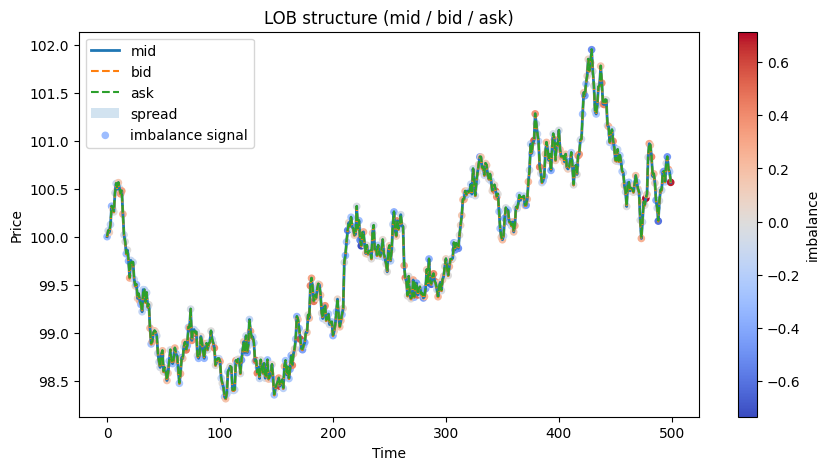

In [22]:
from src.utils.visualisation import plot_lob
import pandas as pd

market = pd.read_csv("data/raw/toy_lob.csv")
plot_lob(market, n_points= 500)

In [25]:
from src.features.market_features import build_market_features

df_feat = build_market_features(market)
print(df_feat.head())
print(df_feat[["mid", "spread", "imbalance", "microprice", "return_1", "ma_10", "ma_20", "rsi_14"]].describe())

          mid         bid         ask  bid_vol  ask_vol  spread  imbalance  \
0  100.000000   99.995000  100.005000      8.0     15.0    0.01  -0.304348   
1  100.062333  100.057333  100.067333      4.0      5.0    0.01  -0.111111   
2  100.044971  100.039971  100.049971     11.0      9.0    0.01   0.100000   
3  100.126287  100.121287  100.131287      8.0     11.0    0.01  -0.157895   
4  100.317655  100.312655  100.322655      8.0     16.0    0.01  -0.333333   

   microprice  return_1       ma_10       ma_20      rsi_14  
0   99.998478  0.000000  100.000000  100.000000    0.000000  
1  100.061778  0.062333  100.031167  100.031167  100.000000  
2  100.045471 -0.017362  100.035768  100.035768   78.214740  
3  100.125498  0.081316  100.058398  100.058398   89.217015  
4  100.315989  0.191368  100.110249  100.110249   95.072984  
                mid        spread     imbalance    microprice      return_1  \
count  10000.000000  1.000000e+04  10000.000000  10000.000000  10000.000000   
m

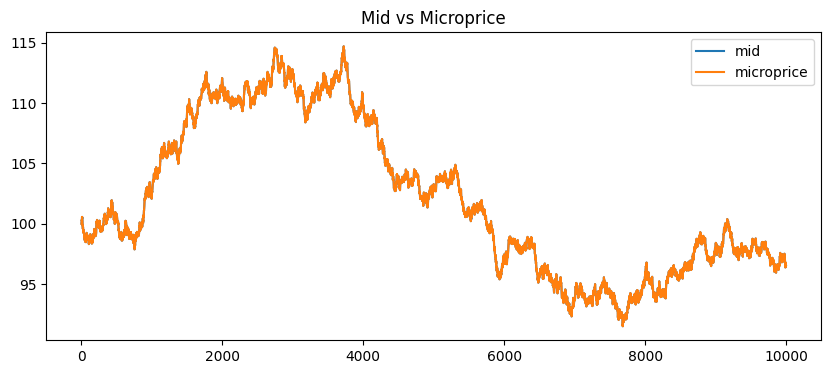

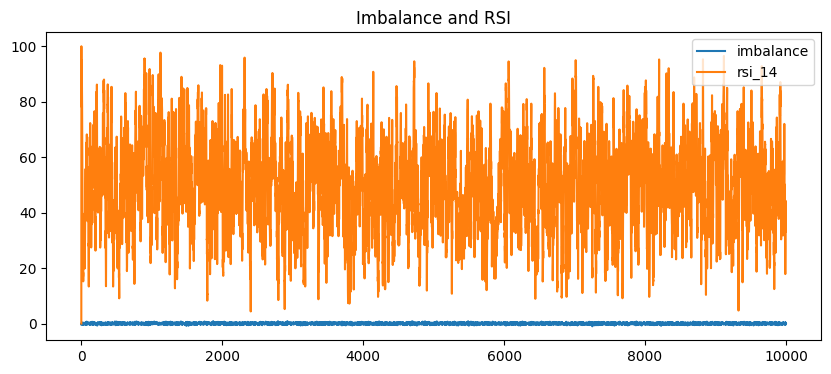

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df_feat["mid"], label="mid")
plt.plot(df_feat["microprice"], label="microprice")
plt.legend()
plt.title("Mid vs Microprice")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(df_feat["imbalance"], label="imbalance")
plt.plot(df_feat["rsi_14"], label="rsi_14")
plt.legend()
plt.title("Imbalance and RSI")
plt.show()